In [1]:
import os, re, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score)

nltk.download("stopwords", quiet=True)
sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/processed/train.csv").dropna().reset_index(drop=True)
test = pd.read_csv("../data/processed/test.csv").dropna().reset_index(drop=True)
X_train, y_train = train["text_clean"], train["label"].values
X_test, y_test = test["text_clean"], test["label"].values


def construire_modele():
    return Pipeline([
        ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000, ngram_range=(1, 2))),
        ("svm", LinearSVC(C=1.0, random_state=42))
    ])


def metriques(y, pred):
    tn, fp_n, fn_n, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"accuracy": accuracy_score(y, pred),
            "précision": precision_score(y, pred, zero_division=0),
            "rappel": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "faux_positifs": int(fp_n), "faux_négatifs": int(fn_n)}

In [2]:
modele = construire_modele()
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Non-spam", "Spam"], digits=4))
print(metriques(y_test, y_pred))

os.makedirs("../models", exist_ok=True)
joblib.dump(modele, "../models/svm_final.joblib")

              precision    recall  f1-score   support

    Non-spam     0.9952    0.9889    0.9921      3159
        Spam     0.9876    0.9946    0.9911      2795

    accuracy                         0.9916      5954
   macro avg     0.9914    0.9918    0.9916      5954
weighted avg     0.9916    0.9916    0.9916      5954

{'accuracy': 0.9916022841787034, 'précision': 0.9875666074600356, 'rappel': 0.9946332737030411, 'f1': 0.9910873440285205, 'faux_positifs': 35, 'faux_négatifs': 15}


['../models/svm_final.joblib']

In [3]:
test["pred"] = y_pred
test["nb_mots"] = test["text_clean"].str.split().str.len()
fp = test[(test["label"] == 0) & (test["pred"] == 1)]
fn = test[(test["label"] == 1) & (test["pred"] == 0)]
print(f"{len(fp)} faux positifs | {len(fn)} faux négatifs\n")

def afficher(df, n=6, seed=1):
    for _, l in df.sample(min(n, len(df)), random_state=seed).iterrows():
        print(f"[{l['nb_mots']} mots] {l['text_clean'][:300]}\n")

print("===== FAUX POSITIFS (emails légitimes classés spam) =====")
afficher(fp)
print("===== FAUX NÉGATIFS (spams non détectés) =====")
afficher(fn)

35 faux positifs | 15 faux négatifs

===== FAUX POSITIFS (emails légitimes classés spam) =====
[14 mots] invitation dinner music started clicking sound icon stop music right click end show heather

[140 mots] eta link hyperlink active eta change number country id accordingly http www enrononline com docs eta eta nombre html uk http www enrononline com docs eta eta nombre html us country id country name nombre argentina nombre australia nombre austria nombre belgium nombre bermuda nombre canada nombre cay

[13 mots] important video announcement important video announcement future company please go access video thank

[181 mots] fw computers happy holidays bonnie hitschel nombre nombre nombre subject computers dear tech support last year upgraded boyfriend nombre nombre husband nombre nombre noticed slowdown performance flower jewelry applications operated flawlessly boyfriend nombre nombre addition husband nombre nombre un

[21 mots] jargon nombre technical terminology characteristic id

In [4]:
test["erreur"] = test["label"] != test["pred"]
test["tranche"] = pd.cut(test["nb_mots"], bins=[0, 20, 50, 100, 200, 500, np.inf],
                         labels=["≤20", "21-50", "51-100", "101-200", "201-500", ">500"])
tab = test.groupby("tranche", observed=True).agg(emails=("erreur", "size"), erreurs=("erreur", "sum"))
tab["taux_erreur_%"] = (100 * tab["erreurs"] / tab["emails"]).round(2)
tab

,emails,erreurs,taux_erreur_%
tranche,,,
≤20,574,23,4.01
21-50,1573,6,0.38
51-100,1483,4,0.27
101-200,1214,12,0.99
201-500,850,5,0.59
>500,260,0,0.00


Seuil retenu : 0.25


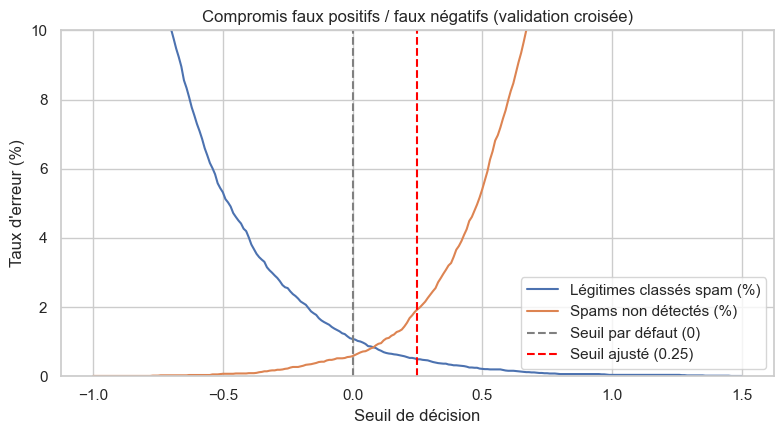

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_oof = cross_val_predict(construire_modele(), X_train, y_train, cv=cv,
                               method="decision_function", n_jobs=-1)

ths = np.linspace(-1.0, 1.5, 251)
n_legit, n_spam = (y_train == 0).sum(), (y_train == 1).sum()
taux_fp = np.array([((scores_oof >= t) & (y_train == 0)).sum() / n_legit for t in ths])
rappel_cv = np.array([((scores_oof >= t) & (y_train == 1)).sum() / n_spam for t in ths])

CIBLE_FP = 0.005                       # au plus 0,5 % d'emails légitimes bloqués
seuil = ths[taux_fp <= CIBLE_FP].min()
print(f"Seuil retenu : {seuil:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ths, 100 * taux_fp, label="Légitimes classés spam (%)")
ax.plot(ths, 100 * (1 - rappel_cv), label="Spams non détectés (%)")
ax.axvline(0, color="gray", ls="--", label="Seuil par défaut (0)")
ax.axvline(seuil, color="red", ls="--", label=f"Seuil ajusté ({seuil:.2f})")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Taux d'erreur (%)")
ax.set_ylim(0, 10)
ax.set_title("Compromis faux positifs / faux négatifs (validation croisée)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/09_seuil_decision.png", dpi=150)
plt.show()

In [6]:
scores_test = modele.decision_function(X_test)
print("AUC sur le test : {:.4f}".format(roc_auc_score(y_test, scores_test)))

lignes = []
for nom, t in [("Seuil par défaut (0)", 0.0), (f"Seuil ajusté ({seuil:.2f})", seuil)]:
    lignes.append({"seuil": nom, **metriques(y_test, (scores_test >= t).astype(int))})
pd.DataFrame(lignes).round(4)

AUC sur le test : 0.9994


,seuil,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs
0,Seuil par défaut (0),0.9916,0.9876,0.9946,0.9911,35,15
1,Seuil ajusté (0.25),0.9884,0.9921,0.9832,0.9876,22,47


In [13]:
stop_words = set(stopwords.words("english")) | {"nbsp", "br"}

def nettoyer(texte):
    texte = str(texte).lower()
    texte = re.sub(r"<[^>]+>", " ", texte)
    texte = re.sub(r"\d+", " nombre ", texte)
    texte = re.sub(r"[^a-z\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return [t for t in texte.split() if t not in stop_words and len(t) > 1]


def charger_corpus(chemin):
    d = pd.read_csv(chemin)
    d["subject"] = d["subject"].fillna("")
    d["body"] = d["body"].fillna("")
    d["text_clean"] = (d["subject"].astype(str) + " " + d["body"].astype(str)).apply(
        lambda t: " ".join(nettoyer(t)))
    n_avant = len(d)
    d = d[d["text_clean"].str.len() > 0].reset_index(drop=True)
    print(f"  {n_avant} emails -> {len(d)} après nettoyage (emails vides retirés : {n_avant - len(d)})")
    d["label"] = d["label"].astype(int)
    return d


def ligne_resultat(corpus, nom_modele, y_vrai, pred):
    m = metriques(y_vrai, pred)
    n_legit = int((np.asarray(y_vrai) == 0).sum())
    n_spam = int((np.asarray(y_vrai) == 1).sum())
    m["taux_FP_%"] = round(100 * m["faux_positifs"] / n_legit, 2)
    m["taux_FN_%"] = round(100 * m["faux_négatifs"] / n_spam, 2)
    return {"corpus": corpus, "modèle": nom_modele, "emails": len(y_vrai),
            "% spam": round(100 * n_spam / len(y_vrai), 1), **m}


lignes = [
    ligne_resultat("Enron (test)", "SVM final", y_test, y_pred),
    ligne_resultat("Enron (test)", "SVM sans marqueurs Enron", y_test, pred_sans),
]

for corpus, chemin in [("Ling", "../data/raw/Ling.csv"), ("SpamAssassin", "../data/raw/SpamAssasin.csv")]:
    print(f"===== {corpus} =====")
    d = charger_corpus(chemin)
    print("  Répartition des classes :", d["label"].value_counts().to_dict())
    print("  Plancher (toujours « non-spam ») : {:.1f} % d'accuracy".format(100 * (d["label"] == 0).mean()))
    print("  Un exemple de chaque classe :")
    for lab, txt in d.groupby("label")["text_clean"].first().items():
        print(f"    label {lab} : {txt[:150]}")
    print()
    for nom_m, m, f in [("SVM final", modele, lambda s: s),
                        ("SVM sans marqueurs Enron", modele_sans, retirer)]:
        pred = m.predict(f(d["text_clean"]))
        lignes.append(ligne_resultat(corpus, nom_m, d["label"].values, pred))

robustesse = pd.DataFrame(lignes)
robustesse.to_csv("../data/processed/resultats_robustesse.csv", index=False)
robustesse.round(4)

===== Ling =====
  2859 emails -> 2859 après nettoyage (emails vides retirés : 0)
  Répartition des classes : {0: 2401, 1: 458}
  Plancher (toujours « non-spam ») : 84.0 % d'accuracy
  Un exemple de chaque classe :
    label 0 : job posting apple iss research center content length nombre apple iss research center us nombre million joint venture apple computer inc institute sys
    label 1 : free multi part message mime format nextpart nombre nombre nombre bd nombre nombre ff nombre nombre content type multipart alternative boundary nextpa

===== SpamAssassin =====
  5809 emails -> 5809 après nettoyage (emails vides retirés : 0)
  Répartition des classes : {0: 4091, 1: 1718}
  Plancher (toujours « non-spam ») : 70.4 % d'accuracy
  Un exemple de chaque classe :
    label 0 : new sequences window date wed nombre aug nombre nombre nombre nombre nombre chris garrigues message id reproduce error repeatable like every time with
    label 1 : life insurance pay save nombre life insurance spend

,corpus,modèle,emails,% spam,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,taux_FP_%,taux_FN_%
0,Enron (test),SVM final,5954,46.9,0.9916,0.9876,0.9946,0.9911,35,15,1.11,0.54
1,Enron (test),SVM sans marqueurs Enron,5954,46.9,0.9884,0.9851,0.9903,0.9877,42,27,1.33,0.97
2,Ling,SVM final,2859,16.0,0.6065,0.2847,0.9629,0.4395,1108,17,46.15,3.71
3,Ling,SVM sans marqueurs Enron,2859,16.0,0.7055,0.3464,0.9454,0.5070,817,25,34.03,5.46
4,SpamAssassin,SVM final,5809,29.6,0.4013,0.3297,0.9919,0.4949,3464,14,84.67,0.81
5,SpamAssassin,SVM sans marqueurs Enron,5809,29.6,0.4305,0.3408,0.9907,0.5072,3292,16,80.47,0.93


In [7]:
for nom, chemin in [("Ling", "../data/raw/Ling.csv"), ("SpamAssassin", "../data/raw/SpamAssasin.csv")]:
    d = pd.read_csv(chemin)
    print(nom, "→", d.shape)
    print("Colonnes :", d.columns.tolist())
    print(d["label"].value_counts().to_dict(), "\n")

Ling → (2859, 3)
Colonnes : ['subject', 'body', 'label']
{0: 2401, 1: 458} 

SpamAssassin → (5809, 7)
Colonnes : ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
{0: 4091, 1: 1718} 



In [8]:
# On ajoute cette variante au tableau comparatif général
chemin = "../data/processed/resultats.csv"
ligne = {"modèle": "SVM optimisé (seuil ajusté)",
         **metriques(y_test, (scores_test >= seuil).astype(int)),
         "f1_validation_croisée": np.nan, "temps_entraînement_s": np.nan}
res = pd.read_csv(chemin)
res = res[res["modèle"] != ligne["modèle"]]
pd.concat([res, pd.DataFrame([ligne])], ignore_index=True).to_csv(chemin, index=False)

In [9]:
MARQUEURS_ENRON = {"enron", "ect", "hou", "hpl", "ena", "vince", "kaminski", "louise", "daren",
                   "hourahead", "westdesk", "dynegy", "houston", "portland", "mmbtu"}

def retirer(serie):
    return serie.apply(lambda t: " ".join(m for m in t.split() if m not in MARQUEURS_ENRON))

modele_sans = construire_modele()
modele_sans.fit(retirer(X_train), y_train)
pred_sans = modele_sans.predict(retirer(X_test))

comparaison = pd.DataFrame([
    {"variante": "Modèle final (texte complet)", **metriques(y_test, y_pred)},
    {"variante": "Sans marqueurs Enron", **metriques(y_test, pred_sans)},
])
comparaison.round(4)

,variante,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs
0,Modèle final (texte complet),0.9916,0.9876,0.9946,0.9911,35,15
1,Sans marqueurs Enron,0.9884,0.9851,0.9903,0.9877,42,27


In [10]:
stop_words = set(stopwords.words("english")) | {"nbsp", "br"}

def nettoyer(texte):
    texte = str(texte).lower()
    texte = re.sub(r"<[^>]+>", " ", texte)
    texte = re.sub(r"\d+", " nombre ", texte)
    texte = re.sub(r"[^a-z\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return [t for t in texte.split() if t not in stop_words and len(t) > 1]


def charger_corpus(chemin):
    d = pd.read_csv(chemin)
    print(chemin, "→", d.shape, d.columns.tolist())
    d["subject"] = d["subject"].fillna("") if "subject" in d.columns else ""
    d["body"] = d["body"].fillna("")
    d["text_clean"] = (d["subject"].astype(str) + " " + d["body"].astype(str)).apply(
        lambda t: " ".join(nettoyer(t)))
    d = d[d["text_clean"].str.len() > 0].reset_index(drop=True)
    d["label"] = d["label"].astype(int)
    return d


lignes = [
    {"corpus": "Enron (test)", "modèle": "SVM final", "emails": len(test), **metriques(y_test, y_pred)},
    {"corpus": "Enron (test)", "modèle": "SVM sans marqueurs Enron", "emails": len(test), **metriques(y_test, pred_sans)},
]

for corpus, chemin in [("Ling", "../data/raw/Ling.csv"), ("SpamAssassin", "../data/raw/SpamAssasin.csv")]:
    d = charger_corpus(chemin)
    print("Répartition des classes :\n", d["label"].value_counts().to_dict())
    print("Exemple de chaque classe :")
    for lab, txt in d.groupby("label")["text_clean"].first().items():
        print(f"  label {lab} : {txt[:150]}")
    print()
    for nom_m, m, f in [("SVM final", modele, lambda s: s),
                        ("SVM sans marqueurs Enron", modele_sans, retirer)]:
        pred = m.predict(f(d["text_clean"]))
        lignes.append({"corpus": corpus, "modèle": nom_m, "emails": len(d), **metriques(d["label"].values, pred)})

robustesse = pd.DataFrame(lignes)
robustesse.to_csv("../data/processed/resultats_robustesse.csv", index=False)
robustesse.round(4)

../data/raw/Ling.csv → (2859, 3) ['subject', 'body', 'label']
Répartition des classes :
 {0: 2401, 1: 458}
Exemple de chaque classe :
  label 0 : job posting apple iss research center content length nombre apple iss research center us nombre million joint venture apple computer inc institute sys
  label 1 : free multi part message mime format nextpart nombre nombre nombre bd nombre nombre ff nombre nombre content type multipart alternative boundary nextpa

../data/raw/SpamAssasin.csv → (5809, 7) ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
Répartition des classes :
 {0: 4091, 1: 1718}
Exemple de chaque classe :
  label 0 : new sequences window date wed nombre aug nombre nombre nombre nombre nombre chris garrigues message id reproduce error repeatable like every time with
  label 1 : life insurance pay save nombre life insurance spend life quote savings ensurin family financial security important life quote savings kes buying life 



,corpus,modèle,emails,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs
0,Enron (test),SVM final,5954,0.9916,0.9876,0.9946,0.9911,35,15
1,Enron (test),SVM sans marqueurs Enron,5954,0.9884,0.9851,0.9903,0.9877,42,27
2,Ling,SVM final,2859,0.6065,0.2847,0.9629,0.4395,1108,17
3,Ling,SVM sans marqueurs Enron,2859,0.7055,0.3464,0.9454,0.5070,817,25
4,SpamAssassin,SVM final,5809,0.4013,0.3297,0.9919,0.4949,3464,14
5,SpamAssassin,SVM sans marqueurs Enron,5809,0.4305,0.3408,0.9907,0.5072,3292,16


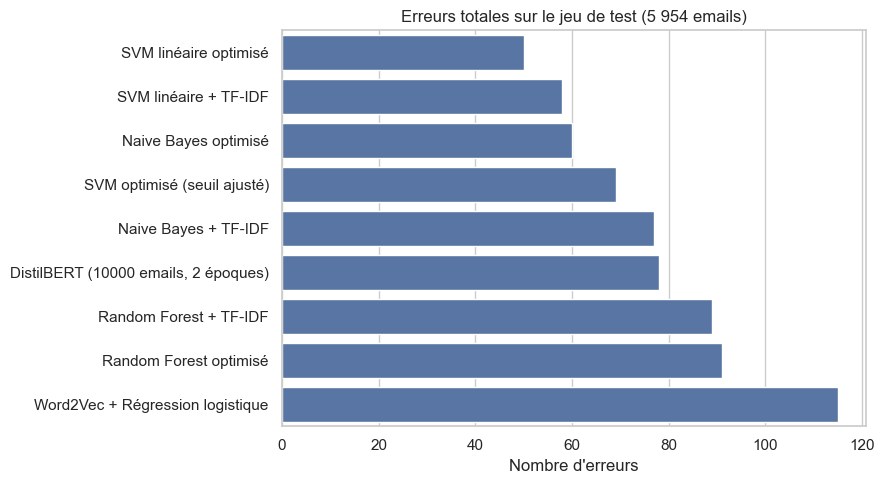

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s,erreurs_totales
5,SVM linéaire optimisé,0.9916,0.9876,0.9946,0.9911,35,15,0.9910,13.93,50
1,SVM linéaire + TF-IDF,0.9903,0.9837,0.9957,0.9897,46,12,0.9899,3.94,58
6,Naive Bayes optimisé,0.9899,0.9886,0.9900,0.9893,32,28,0.9887,0.69,60
8,SVM optimisé (seuil ajusté),0.9884,0.9921,0.9832,0.9876,22,47,NaN,NaN,69
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.9850,4.40,77
4,"DistilBERT (10000 emails, 2 époques)",0.9869,0.9860,0.9860,0.9860,39,39,NaN,205.80,78
2,Random Forest + TF-IDF,0.9851,0.9771,0.9914,0.9842,65,24,0.9842,11.90,89
7,Random Forest optimisé,0.9847,0.9808,0.9868,0.9838,54,37,0.9849,11.37,91
3,Word2Vec + Régression logistique,0.9807,0.9722,0.9871,0.9796,79,36,0.9779,37.78,115


In [11]:
res = pd.read_csv("../data/processed/resultats.csv")
res["erreurs_totales"] = res["faux_positifs"] + res["faux_négatifs"]
res = res.sort_values("erreurs_totales")

plt.figure(figsize=(9, 5))
sns.barplot(data=res, y="modèle", x="erreurs_totales", color="#4C72B0")
plt.title("Erreurs totales sur le jeu de test (5 954 emails)")
plt.xlabel("Nombre d'erreurs")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../images/09_comparaison_modeles.png", dpi=150)
plt.show()

res.round(4)

In [12]:
for nom, d in [("FAUX POSITIFS", fp), ("FAUX NÉGATIFS", fn)]:
    print(f"\n===== {nom} ({len(d)}) =====")
    for i, (_, l) in enumerate(d.iterrows(), 1):
        print(f"{i:2d}. [{l['nb_mots']} mots] {l['text_clean'][:200]}")


===== FAUX POSITIFS (35) =====
 1. [19 mots] rodrigo lamas best wishes would like take opportunity let know resigned today wish best carreer life regards rodrigo lamas
 2. [191 mots] fw invitacion la nombre conferencia de enron de mexico sept nombre nombre nombre guys fyi sent invitation conference customer list details want send someone else mention babby badges ready remember st
 3. [23 mots] delano delano ramped nombre nombre buy replace remember delano generation costs split upside might want try avoid nombre little risky keep mind leaf
 4. [13 mots] important video announcement important video announcement future company please go access video thank
 5. [307 mots] investment may concern keep receiving unsolicited messages please see represent obvious scam way block messages source assume employees enron also hit vince kaminski forwarded vince kaminski hou ect n
 6. [12 mots] singles debate hey check dude smashing pumkins song drown find cd whaz
 7. [155 mots] get nombre certifica

In [14]:
vocab = modele.named_steps["tfidf"].vocabulary_

def part_mots_connus(textes):
    taux = []
    for t in textes:
        mots = t.split()
        if mots:
            taux.append(np.mean([m in vocab for m in mots]))
    return np.mean(taux)

ling = charger_corpus("../data/raw/Ling.csv")
sa = charger_corpus("../data/raw/SpamAssasin.csv")

lignes = []
for nom, d in [("Enron (test)", test), ("Ling", ling), ("SpamAssassin", sa)]:
    scores = modele.decision_function(d["text_clean"])
    lab = d["label"].values
    lignes.append({"corpus": nom,
                   "% mots connus": round(100 * part_mots_connus(d["text_clean"]), 1),
                   "score moyen (légitimes)": round(scores[lab == 0].mean(), 2),
                   "score moyen (spams)": round(scores[lab == 1].mean(), 2)})
pd.DataFrame(lignes)

  2859 emails -> 2859 après nettoyage (emails vides retirés : 0)
  5809 emails -> 5809 après nettoyage (emails vides retirés : 0)


,corpus,% mots connus,score moyen (légitimes),score moyen (spams)
0,Enron (test),90.7,-1.54,1.18
1,Ling,80.8,-0.04,0.99
2,SpamAssassin,85.6,0.42,1.22


In [15]:
import pandas as pd

res = pd.read_csv("../data/processed/resultats.csv")
bert = pd.read_csv("../data/processed/resultat_bert.csv")
res = res[~res["modèle"].str.startswith("DistilBERT")]
res = pd.concat([res, bert], ignore_index=True)
res.to_csv("../data/processed/resultats.csv", index=False)
res["erreurs_totales"] = res["faux_positifs"] + res["faux_négatifs"]
res.sort_values("erreurs_totales").round(4)

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s,erreurs_totales
4,SVM linéaire optimisé,0.9916,0.9876,0.9946,0.9911,35,15,0.9910,13.93,50
1,SVM linéaire + TF-IDF,0.9903,0.9837,0.9957,0.9897,46,12,0.9899,3.94,58
5,Naive Bayes optimisé,0.9899,0.9886,0.9900,0.9893,32,28,0.9887,0.69,60
7,SVM optimisé (seuil ajusté),0.9884,0.9921,0.9832,0.9876,22,47,NaN,NaN,69
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.9850,4.40,77
8,"DistilBERT (10000 emails, 2 époques)",0.9852,0.9829,0.9857,0.9843,48,40,NaN,209.80,88
2,Random Forest + TF-IDF,0.9851,0.9771,0.9914,0.9842,65,24,0.9842,11.90,89
6,Random Forest optimisé,0.9847,0.9808,0.9868,0.9838,54,37,0.9849,11.37,91
3,Word2Vec + Régression logistique,0.9807,0.9722,0.9871,0.9796,79,36,0.9779,37.78,115
